In [2]:
import pandas as pd

# Load Auto dataset from raw GitHub URL and store as `auto`
url = 'https://raw.githubusercontent.com/fedscornell/MachineLearning25/main/Auto.csv'
auto = pd.read_csv(url)
print(' Shape:', auto.shape)

auto.head()

 Shape: (392, 9)


,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin,name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino


In [ ]:
#### 14 
### a.

mpg01 = (auto['mpg'] >= auto['mpg'].median()).astype(int)

auto['mpg01'] = mpg01


,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin,name,mpg01
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu,0
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320,0
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite,0
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst,0
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino,0


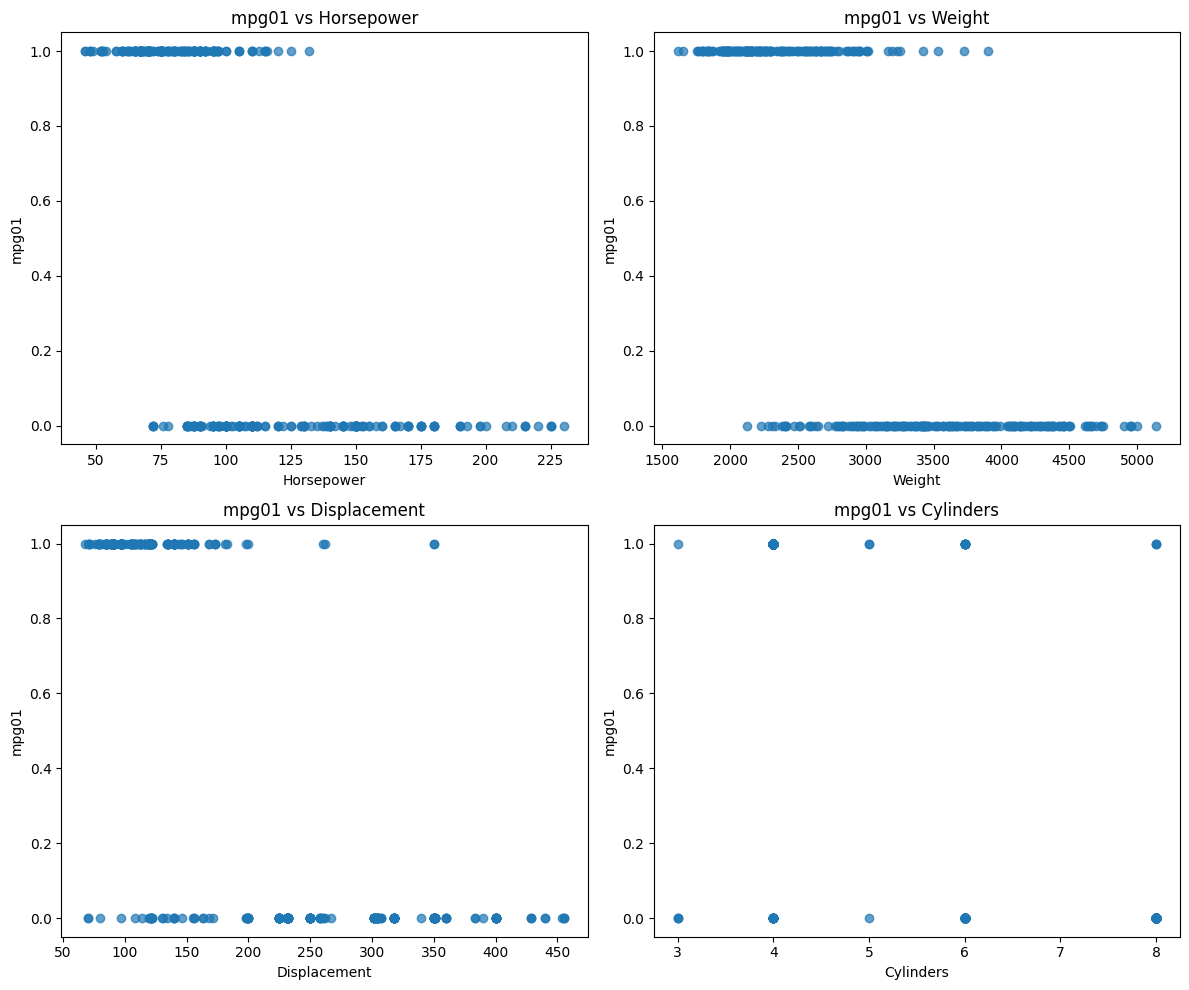

In [ ]:
import matplotlib.pyplot as plt


#### b. 


# Plot mpg01 against horsepower, weight, displacement, and cylinders in a 2x2 grid
plt.figure(figsize=(12, 10))

plt.subplot(2, 2, 1)
plt.scatter(auto['horsepower'], auto['mpg01'], alpha=0.7)
plt.xlabel('Horsepower')
plt.ylabel('mpg01')
plt.title('mpg01 vs Horsepower')

plt.subplot(2, 2, 2)
plt.scatter(auto['weight'], auto['mpg01'], alpha=0.7)
plt.xlabel('Weight')
plt.ylabel('mpg01')
plt.title('mpg01 vs Weight')

plt.subplot(2, 2, 3)
plt.scatter(auto['displacement'], auto['mpg01'], alpha=0.7)
plt.xlabel('Displacement')
plt.ylabel('mpg01')
plt.title('mpg01 vs Displacement')

plt.subplot(2, 2, 4)
plt.scatter(auto['cylinders'], auto['mpg01'], alpha=0.7)
plt.xlabel('Cylinders')
plt.ylabel('mpg01')
plt.title('mpg01 vs Cylinders')

plt.tight_layout()
plt.show()


### I added only scatter plots becasue I believe that the amount of overlap between the two classes can speak to how well each feature can predict mpg01. I belive that when there is a sharp constrast such as in the horsepower it shows clearly that the higher horsepower almost certainly means below median mpg. Weight is similar. The cyclinders appears to have no bearing on mpg as engines with any cylinders have high or low mpg. Displacemnet has a gradient for low mpg cars but high mpg cars seem to almost exclusively be below 200 displacement indicating the size of the engine. 

In [ ]:
#### c

from sklearn.model_selection import train_test_split

# Example: split auto into X (features) and y (target)
X = auto[['horsepower', 'weight', 'displacement']]
y = auto['mpg01']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [ ]:
#### d

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import confusion_matrix, accuracy_score
import pandas as pd

# Features selected (use the ones that appeared most associated with mpg01)
features = ['horsepower', 'weight', 'displacement']

# Ensure X_train/X_test are present; they were created earlier using these features
# Fit LDA on training data
lda = LinearDiscriminantAnalysis()
lda.fit(X_train, y_train)

# Class means and priors
means_df = pd.DataFrame(lda.means_, columns=features)
means_df.index = ['mpg01=0 (low)', 'mpg01=1 (high)']
print('Class means for each predictor:')
print(means_df)

print('\nPrior probabilities:')
for label, prior in zip(['mpg01=0 (low)', 'mpg01=1 (high)'], lda.priors_):
    print(f'{label}: {prior:.4f}')

# Predict on test set and evaluate
lda_pred = lda.predict(X_test)
lda_cm = confusion_matrix(y_test, lda_pred)
lda_acc = accuracy_score(y_test, lda_pred)
test_error = 1 - accuracy_score(y_test, lda_pred)

print('\nLDA Confusion Matrix:')
print(lda_cm)
print(f'LDA Test Accuracy: {lda_acc:.4f}')
print(f'LDA Test Error: {test_error}')

# Optionally show predicted probabilities for the first five test rows
if hasattr(lda, 'predict_proba'):
    probs = lda.predict_proba(X_test)[:5]
    print('\nFirst 5 predicted probabilities (P(mpg01=0), P(mpg01=1)) for X_test:')
    print(probs)




Class means for each predictor:
                horsepower       weight  displacement
mpg01=0 (low)   132.488550  3660.442748    281.641221
mpg01=1 (high)   79.594406  2369.083916    118.972028

Prior probabilities:
mpg01=0 (low): 0.4781
mpg01=1 (high): 0.5219

LDA Confusion Matrix:
[[46 19]
 [ 0 53]]
LDA Test Accuracy: 0.8390
LDA Test Error: 0.1610169491525424

First 5 predicted probabilities (P(mpg01=0), P(mpg01=1)) for X_test:
[[0.01287111 0.98712889]
 [0.06000875 0.93999125]
 [0.00543194 0.99456806]
 [0.00693705 0.99306295]
 [0.11545293 0.88454707]]


In [ ]:
### e

from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.metrics import confusion_matrix, accuracy_score
import pandas as pd

# Fit QDA on training data
qda = QuadraticDiscriminantAnalysis()
qda.fit(X_train, y_train)

# Class means and priors
means_qda = pd.DataFrame(qda.means_, columns=features)
means_qda.index = ['mpg01=0 (low)', 'mpg01=1 (high)']
print('QDA class means for each predictor:')
print(means_qda)

print('\nQDA prior probabilities:')
for label, prior in zip(['mpg01=0 (low)', 'mpg01=1 (high)'], qda.priors_):
    print(f'{label}: {prior:.4f}')

# Covariance matrices (one per class)
if hasattr(qda, 'covariance_'):
    print('\nCovariance matrices (class 0 then class 1):')
    for i, cov in enumerate(qda.covariance_):
        print(f'Class {i} covariance:\n', cov)

# Predict on test set and evaluate
qda_pred = qda.predict(X_test)
qda_cm = confusion_matrix(y_test, qda_pred)
qda_acc = accuracy_score(y_test, qda_pred)
qda_error = 1 - qda_acc

print('\nQDA Confusion Matrix:')
print(qda_cm)
print(f'QDA Test Accuracy: {qda_acc:.4f}')
print(f'QDA Test Error:    {qda_error:.4f}')

# Show first 5 predicted probabilities if available
if hasattr(qda, 'predict_proba'):
    probs_qda = qda.predict_proba(X_test)[:5]
    print('\nFirst 5 predicted probabilities (P(mpg01=0), P(mpg01=1)) for X_test:')
    print(probs_qda)

QDA class means for each predictor:
                horsepower       weight  displacement
mpg01=0 (low)   132.488550  3660.442748    281.641221
mpg01=1 (high)   79.594406  2369.083916    118.972028

QDA prior probabilities:
mpg01=0 (low): 0.4781
mpg01=1 (high): 0.5219

QDA Confusion Matrix:
[[46 19]
 [ 1 52]]
QDA Test Accuracy: 0.8305
QDA Test Error:    0.1695

First 5 predicted probabilities (P(mpg01=0), P(mpg01=1)) for X_test:
[[0.01257023 0.98742977]
 [0.20227842 0.79772158]
 [0.0122775  0.9877225 ]
 [0.00774483 0.99225517]
 [0.07875337 0.92124663]]


In [25]:
### f

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

# Fit logistic regression on training data
logreg = LogisticRegression(solver='liblinear')
logreg.fit(X_train, y_train)

# Predict on test set
logreg_pred = logreg.predict(X_test)
logreg_proba = logreg.predict_proba(X_test)[:,1]

# Metrics
logreg_acc = accuracy_score(y_test, logreg_pred)
logreg_error = 1 - logreg_acc
logreg_cm = confusion_matrix(y_test, logreg_pred)

print('Logistic Regression Confusion Matrix:')
print(logreg_cm)
print(f'Logistic Regression Test Accuracy: {logreg_acc:.4f}')
print(f'Logistic Regression Test Error:    {logreg_error:.4f}\n')
print('Classification report:')
print(classification_report(y_test, logreg_pred))

# Coefficients (mapped to features)
coef_df = pd.Series(logreg.coef_[0], index=features)
print('\nLogistic regression coefficients:')
print(coef_df)

# Show first 5 predicted probabilities
print('\nFirst 5 predicted probabilities for class mpg01=1:')
print(logreg_proba[:5])

Logistic Regression Confusion Matrix:
[[47 18]
 [ 2 51]]
Logistic Regression Test Accuracy: 0.8305
Logistic Regression Test Error:    0.1695

Classification report:
              precision    recall  f1-score   support

           0       0.96      0.72      0.82        65
           1       0.74      0.96      0.84        53

    accuracy                           0.83       118
   macro avg       0.85      0.84      0.83       118
weighted avg       0.86      0.83      0.83       118


Logistic regression coefficients:
horsepower     -0.012127
weight          0.001273
displacement   -0.033441
dtype: float64

First 5 predicted probabilities for class mpg01=1:
[0.90855263 0.84210276 0.88865281 0.89596524 0.79961237]


In [26]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

# Fit Gaussian Naive Bayes on training data
nb = GaussianNB()
nb.fit(X_train, y_train)

# Predict on test set
nb_pred = nb.predict(X_test)
nb_proba = nb.predict_proba(X_test)[:,1] if hasattr(nb, 'predict_proba') else None

# Metrics
nb_acc = accuracy_score(y_test, nb_pred)
nb_error = 1 - nb_acc
nb_cm = confusion_matrix(y_test, nb_pred)

print('Naive Bayes Confusion Matrix:')
print(nb_cm)
print(f'Naive Bayes Test Accuracy: {nb_acc:.4f}')
print(f'Naive Bayes Test Error:    {nb_error:.4f}\n')
print('Classification report:')
print(classification_report(y_test, nb_pred))

# Show first 5 predicted probabilities if available
if nb_proba is not None:
    print('\nFirst 5 predicted probabilities for class mpg01=1:')
    print(nb_proba[:5])

# Optionally print class-wise means used by GaussianNB
if hasattr(nb, 'theta_'):
    means_nb = pd.DataFrame(nb.theta_, columns=features, index=['mpg01=0','mpg01=1'])
    print('\nClass means (GaussianNB):')
    print(means_nb)

Naive Bayes Confusion Matrix:
[[47 18]
 [ 1 52]]
Naive Bayes Test Accuracy: 0.8390
Naive Bayes Test Error:    0.1610

Classification report:
              precision    recall  f1-score   support

           0       0.98      0.72      0.83        65
           1       0.74      0.98      0.85        53

    accuracy                           0.84       118
   macro avg       0.86      0.85      0.84       118
weighted avg       0.87      0.84      0.84       118


First 5 predicted probabilities for class mpg01=1:
[0.99974686 0.88226022 0.9998815  0.99985489 0.98909769]

Class means (GaussianNB):
         horsepower       weight  displacement
mpg01=0  132.488550  3660.442748    281.641221
mpg01=1   79.594406  2369.083916    118.972028


In [37]:
### g - KNN (compare: primary k=3)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

# Fit KNN for several k values and report accuracies; make k=3 the primary
knn2 = KNeighborsClassifier(n_neighbors=2)
knn3 = KNeighborsClassifier(n_neighbors=3)
knn4 = KNeighborsClassifier(n_neighbors=4)
knn6 = KNeighborsClassifier(n_neighbors=6)

# Train all
knn2.fit(X_train, y_train)
knn3.fit(X_train, y_train)
knn4.fit(X_train, y_train)
knn6.fit(X_train, y_train)

# Predict
knn2_pred = knn2.predict(X_test)
knn3_pred = knn3.predict(X_test)
knn4_pred = knn4.predict(X_test)
knn6_pred = knn6.predict(X_test)

# Accuracies
knn2_acc = accuracy_score(y_test, knn2_pred)
knn3_acc = accuracy_score(y_test, knn3_pred)
knn4_acc = accuracy_score(y_test, knn4_pred)
knn6_acc = accuracy_score(y_test, knn6_pred)

print(f'KNN (k=2) Test Accuracy: {knn2_acc:.4f}')
print(f'KNN (k=3) Test Accuracy: {knn3_acc:.4f}')
print(f'KNN (k=4) Test Accuracy: {knn4_acc:.4f}')
print(f'KNN (k=6) Test Accuracy: {knn6_acc:.4f}\n')

# Make k=3 the primary reported classifier: confusion matrix + classification report
knn3_cm = confusion_matrix(y_test, knn3_pred)
knn3_error = 1 - knn3_acc

print('KNN (k=3) Confusion Matrix:')
print(knn3_cm)
print(f'KNN (k=3) Test Error:    {knn3_error:.4f}\n')
print('Classification report (k=3):')
print(classification_report(y_test, knn3_pred))

# Optionally show first 5 predicted neighbors' indices and distances for k=3
if hasattr(knn3, 'kneighbors'):
    neigh_dist, neigh_idx = knn3.kneighbors(X_test[:5])
    print('\nFirst 5 test rows - neighbor distances (k=3):')
    print(neigh_dist)
    print('First 5 test rows - neighbor indices (k=3):')
    print(neigh_idx)

KNN (k=2) Test Accuracy: 0.8475
KNN (k=3) Test Accuracy: 0.8644
KNN (k=4) Test Accuracy: 0.8559
KNN (k=6) Test Accuracy: 0.8475

KNN (k=3) Confusion Matrix:
[[50 15]
 [ 1 52]]
KNN (k=3) Test Error:    0.1356

Classification report (k=3):
              precision    recall  f1-score   support

           0       0.98      0.77      0.86        65
           1       0.78      0.98      0.87        53

    accuracy                           0.86       118
   macro avg       0.88      0.88      0.86       118
weighted avg       0.89      0.86      0.86       118


First 5 test rows - neighbor distances (k=3):
[[ 9.11043358  9.11043358 10.34408043]
 [36.74234614 37.65634077 38.32753579]
 [ 8.60232527  8.60232527  9.21954446]
 [10.44030651 11.66190379 13.34166406]
 [26.77685568 35.12833614 42.90687591]]
First 5 test rows - neighbor indices (k=3):
[[224   9 173]
 [ 31  58  89]
 [ 87  76 234]
 [129  36 116]
 [ 31  37  58]]


In [ ]:


print(f'LDA Test Accuracy: {lda_acc:.4f}')
print(f'QDA Test Accuracy: {qda_acc:.4f}')
print(f'Logistic Regression Test Accuracy: {logreg_acc:.4f}')
print(f'Naive Bayes Test Accuracy: {nb_acc:.4f}')
print(f'KNN (k=3) Test Accuracy: {knn3_acc:.4f}')



### very quickly I belive that k=3 works the best becasue the functional form cannot be known. And the k = 3 is teh sweet spot for bias and variance. 




LDA Test Accuracy: 0.8390
QDA Test Accuracy: 0.8305
Logistic Regression Test Accuracy: 0.8305
Naive Bayes Test Accuracy: 0.8390
KNN (k=3) Test Accuracy: 0.8644


In [ ]:
import numpy as np

rng = np.random.default_rng(1)
x = rng.normal(size=100)
y = x - 2 * x**2 + rng.normal(size=100)

### n = 100 p = 2 



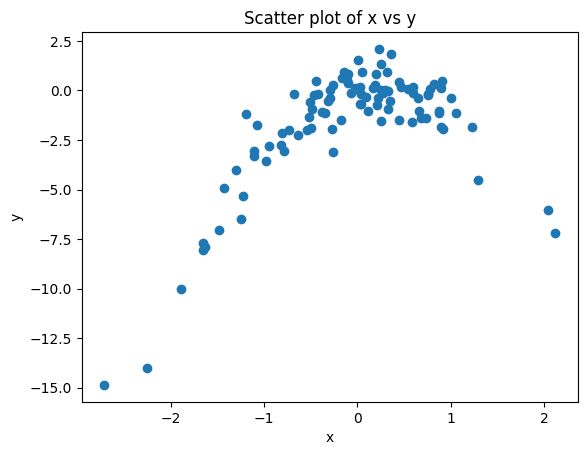

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(x, y)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Scatter plot of x vs y')
plt.show()

### looks like the relationship is concave (negative squared form) and of course centers around 0.


In [55]:
# Create a single DataFrame combining x and y, then fit linear and quadratic OLS
import pandas as pd
import statsmodels.api as sm

df = pd.DataFrame({'x': x, 'y': y})

# Add columns for x**2, x**3, and x**4
df['x2'] = df['x'] ** 2
df['x3'] = df['x'] ** 3
df['x4'] = df['x'] ** 4

df

,x,y,x2,x3,x4
0,0.345584,-0.544554,0.119428,0.041273,0.014263
1,0.821618,0.333950,0.675056,0.554639,0.455701
2,0.330437,-0.013532,0.109189,0.036080,0.011922
3,-1.303157,-4.030442,1.698219,-2.213046,2.883947
4,0.905356,0.484861,0.819669,0.742092,0.671858
...,...,...,...,...,...
95,-2.250854,-14.001012,5.066345,-11.403604,25.667851
96,-0.138655,0.932532,0.019225,-0.002666,0.000370
97,0.033000,0.198928,0.001089,0.000036,0.000001
98,-1.425349,-4.940183,2.031620,-2.895767,4.127478


In [57]:
import statsmodels.api as sm

# Fit a regression of y on x, including an intercept
X = sm.add_constant(df['x'])  # adds intercept
model = sm.OLS(df['y'], X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.318
Model:                            OLS   Adj. R-squared:                  0.311
Method:                 Least Squares   F-statistic:                     45.60
Date:                Wed, 15 Oct 2025   Prob (F-statistic):           1.04e-09
Time:                        14:50:50   Log-Likelihood:                -230.83
No. Observations:                 100   AIC:                             465.7
Df Residuals:                      98   BIC:                             470.9
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -1.4650      0.247     -5.937      0.0

In [62]:
import statsmodels.api as sm

# Fit a regression of y on x and x2 (quadratic regression)
X_2_ = sm.add_constant(df[['x', 'x2']])  # includes intercept, x, x^2
model_quad = sm.OLS(df['y'], X_2_).fit()
print(model_quad.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.887
Model:                            OLS   Adj. R-squared:                  0.884
Method:                 Least Squares   F-statistic:                     379.5
Date:                Wed, 15 Oct 2025   Prob (F-statistic):           1.36e-46
Time:                        14:53:18   Log-Likelihood:                -141.06
No. Observations:                 100   AIC:                             288.1
Df Residuals:                      97   BIC:                             295.9
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0728      0.119     -0.611      0.5

In [63]:
X_3_ = sm.add_constant(df[['x', 'x2', 'x3']])  # includes intercept, x, x^2
model_quad = sm.OLS(df['y'], X_3_).fit()
print(model_quad.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.888
Model:                            OLS   Adj. R-squared:                  0.885
Method:                 Least Squares   F-statistic:                     253.8
Date:                Wed, 15 Oct 2025   Prob (F-statistic):           1.70e-45
Time:                        14:53:42   Log-Likelihood:                -140.47
No. Observations:                 100   AIC:                             288.9
Df Residuals:                      96   BIC:                             299.4
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0572      0.120     -0.477      0.6

In [ ]:
X_4_ = sm.add_constant(df[['x', 'x2', 'x3', 'x4']])  # includes intercept, x, x^2
model_quad = sm.OLS(df['y'], X_4_).fit()
print(model_quad.summary())



                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.894
Model:                            OLS   Adj. R-squared:                  0.890
Method:                 Least Squares   F-statistic:                     200.2
Date:                Wed, 15 Oct 2025   Prob (F-statistic):           2.22e-45
Time:                        14:55:10   Log-Likelihood:                -137.74
No. Observations:                 100   AIC:                             285.5
Df Residuals:                      95   BIC:                             298.5
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1008      0.136      0.743      0.4

In [82]:
from sklearn.model_selection import LeaveOneOut
from sklearn.linear_model import LinearRegression
import numpy as np

# Prepare X and y for each model
X1 = df[['x']].values
X2 = df[['x', 'x2']].values
X3 = df[['x', 'x2', 'x3']].values
X4 = df[['x', 'x2', 'x3', 'x4']].values
y = df['y'].values

loocv = LeaveOneOut()

# Function to compute LOOCV MSE for a given X
def loocv_mse(X, y):
	errors = []
	for train_idx, test_idx in loocv.split(X):
		model = LinearRegression()
		model.fit(X[train_idx], y[train_idx])
		y_pred = model.predict(X[test_idx])
		errors.append((y[test_idx][0] - y_pred[0]) ** 2)
	return np.mean(errors)

# Compute LOOCV MSE for each model
mse1 = loocv_mse(X1, y)
mse2 = loocv_mse(X2, y)
mse3 = loocv_mse(X3, y)
mse4 = loocv_mse(X4, y)

print(f"LOOCV MSE (x only): {mse1:.4f}")
print(f"LOOCV MSE (x + x2): {mse2:.4f}")
print(f"LOOCV MSE (x + x2 + x3): {mse3:.4f}")
print(f"LOOCV MSE (x + x2 + x3 + x4): {mse4:.4f}")

# Store results as a list of tuples: (degree, mse)
results = [
	(1, mse1),
	(2, mse2),
	(3, mse3),
	(4, mse4)
]

LOOCV MSE (x only): 6.6330
LOOCV MSE (x + x2): 1.1229
LOOCV MSE (x + x2 + x3): 1.3018
LOOCV MSE (x + x2 + x3 + x4): 1.3324


In [ ]:
### d 

rng2 = np.random.default_rng(43)
xi = rng2.normal(size=100)
yi = xi - 2 * xi**2 + rng2.normal(size=100)



### n = 100 p = 2 

In [84]:
dfi = pd.DataFrame({'x': xi, 'y': yi})

# Add columns for x**2, x**3, and x**4
dfi['x2'] = dfi['x'] ** 2
dfi['x3'] = dfi['x'] ** 3
dfi['x4'] = dfi['x'] ** 4

dfi

,x,y,x2,x3,x4
0,0.244230,-0.139727,0.059648,0.014568,0.003558
1,0.678178,-1.265716,0.459926,0.311912,0.211532
2,-0.585529,-0.219289,0.342845,-0.200746,0.117542
3,-0.908673,-1.573068,0.825687,-0.750279,0.681759
4,-1.991838,-10.392082,3.967419,-7.902458,15.740417
...,...,...,...,...,...
95,-0.562259,-0.517004,0.316135,-0.177750,0.099941
96,0.042377,-1.511337,0.001796,0.000076,0.000003
97,-2.357517,-13.407237,5.557884,-13.102805,30.890079
98,-0.520363,-2.463650,0.270778,-0.140903,0.073321


In [ ]:
# Prepare X and y for each model
X1 = dfi[['x']].values
X2 = dfi[['x', 'x2']].values
X3 = dfi[['x', 'x2', 'x3']].values
X4 = dfi[['x', 'x2', 'x3', 'x4']].values
y = dfi['y'].values

loocv = LeaveOneOut()

# Function to compute LOOCV MSE for a given X
def loocv_mse(X, y):
	errors = []
	for train_idx, test_idx in loocv.split(X):
		model = LinearRegression()
		model.fit(X[train_idx], y[train_idx])
		y_pred = model.predict(X[test_idx])
		errors.append((y[test_idx][0] - y_pred[0]) ** 2)
	return np.mean(errors)

# Compute LOOCV MSE for each model
mse1 = loocv_mse(X1, y)
mse2 = loocv_mse(X2, y)
mse3 = loocv_mse(X3, y)
mse4 = loocv_mse(X4, y)

print(f"LOOCV MSE (x only): {mse1:.4f}")
print(f"LOOCV MSE (x + x2): {mse2:.4f}")
print(f"LOOCV MSE (x + x2 + x3): {mse3:.4f}")
print(f"LOOCV MSE (x + x2 + x3 + x4): {mse4:.4f}")

# Store results as a list of tuples: (degree, mse)
results = [
	(1, mse1),
	(2, mse2),
	(3, mse3),
	(4, mse4)
]

##### there is a slight difference becasue of the randomness in creating a new data set. But the models are still very similar and show that the quadratic model is best.

#### e. The model with the lowest mse was the quadratic, which is obvious as we created the variable y from a quadratic form of x.

#### f using OLS which is done before the LOOCV in this code, we see that when the quadratic model is used beta2 for X2 is signifiacnt, where the intercept beta0 is not signifiacntly different from 0. This is becasue fo the functional form we used to create the data. For the lienar model Beta1 and Beta0 capture the effects of the true function and although both being statstically significant, the functional form is not linear.
#### These conclusions certainly agree with the findings of the LOOCV that the quadratic model is best.

LOOCV MSE (x only): 11.7290
LOOCV MSE (x + x2): 1.1366
LOOCV MSE (x + x2 + x3): 1.1610
LOOCV MSE (x + x2 + x3 + x4): 1.1664


In [ ]:
### 1.

##training Rss for any model with k predictors included will be lowest for best subset selcetion, becasue assuming that there is no computational limit, the model will test every possible combination of preditocrs for any level k, resulting in the best fit for the number of k, whereas for forward and backwards some of the predictors that would be good at k may have been eliminated.
### Test rss will probably not be lowest with Best subset as it is more likely to overfit the training data. However if k is lower, than presumably forward selection will be better, and if k is higher than backward selection may be more appropriate.
## i. True, becasue the k+1-variable model will have the same exact predictors as the k-variable model, plus one additional predictor. The additional predictor is added in addition to the already selected vairables. 
## ii. True, because the k+1 variable model will have the exact same predictors, but with one additional predictor. The k+1 model comes before the k model in backwards selection. 
## iii. false, this is not necessarily true because the k+1 variable model for forward slection may have chosen a totally different predictor, becasue it is moving from which predictor is best at k=1 locking it in then moving to which is best at k=2, whereas the backwards is removing the worst predictor from k = p then again at  k = p-1 etc. 
## iv. false, for the same reason above.
## v. false, becasue the best subset, doesn't have to include the same predictors in k as it did in k-1, it is looking at the best predictors for that specific k.  


In [ ]:
### 2. 

### a. iii. Lasso is less flexible than OLS becasue of the l1 penalty, and so it is going to have a higher variance and lower bias, but the decrease in bias outweighs the increase in variance. 
### b. iii Same as above but with an l2 penalty
### c. i. A non-linear model is more flexible and we would prefer variance to decrease and if need be bias to increase so that there can be better predictive power and less overfitting. 